# Customer Churn Prediction using 1D-CNN

## 1. Environment Setup and Reproducibility
In this section, we import the necessary libraries for data manipulation, visualization, machine learning preprocessing, and deep learning modeling using PyTorch. 

To ensure consistent and reproducible results across runs, random seeds are set for both NumPy and PyTorch. Additionally, Seaborn styling is configured for clean visualization outputs.

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, roc_auc_score, roc_curve

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set plot aesthetic theme
sns.set_theme(style = "whitegrid")


## 2. Data Ingestion and Structural Overview
In this step, the dataset is loaded into a Pandas DataFrame. We perform an initial quality check to inspect sample records, examine data dimensions, verify feature data types, and check for missing values across all columns.

In [116]:
# Load dataset into a DataFrame
df = pd.read_csv('customer_subscription_churn_usage_patterns.csv')

# Display the first 5 rows
print(f"\n\n{df.head()}\n\n")

# Dataset dimensions (rows and columns)
print(f"Total rows and columns: {df.shape}\n\n")

# Column data types and memory usage
print(f"{df.info()}\n\n")

# Check for missing values per column
print(df.isnull().sum())





   user_id signup_date plan_type  monthly_fee  avg_weekly_usage_hours  \
0        1  2023-04-15   Premium          699                     1.1   
1        2  2023-08-27   Premium          699                     2.6   
2        3  2023-10-12   Premium          699                    14.3   
3        4  2023-12-11     Basic          199                    17.6   
4        5  2023-02-14     Basic          199                     9.8   

   support_tickets  payment_failures  tenure_months  last_login_days_ago churn  
0                4                 1              8                   14   Yes  
1                6                 0             35                    1   Yes  
2                8                 3              2                   14   Yes  
3                5                 2             11                    9   Yes  
4                5                 2              6                   38   Yes  


Total rows and columns: (2800, 10)


<class 'pandas.DataFrame'>
RangeIn

## 3. Data Cleaning and Statistical Summary
In this step, non-informative identifier and date features (`user_id` and `signup_date`) are removed to prevent data leakage and avoid introducing spurious patterns into the model. 

We then verify the remaining feature set and compute descriptive statistics to understand the central tendency, dispersion, and scale of numerical attributes.

In [117]:
df = df.drop(columns = ["user_id", "signup_date"])

# Remaining columns
print(df.columns.tolist())

df.head()

# Descriptive statistics for numerical columns
df.describe()

['plan_type', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'churn']


,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


## 4. Exploratory Data Analysis
In this section, we analyze the distribution of the target variable (`churn`) and inspect inter-feature relationships. 

Examining class frequencies helps determine the extent of class imbalance, which informs loss function weighting and decision threshold tuning. Additionally, a correlation heatmap is generated to detect potential linear dependencies among numerical features.

Target Class Counts:
churn
Yes    1605
No     1195
Name: count, dtype: int64

Target Class Proportions (%):
churn
Yes    57.321429
No     42.678571
Name: proportion, dtype: float64


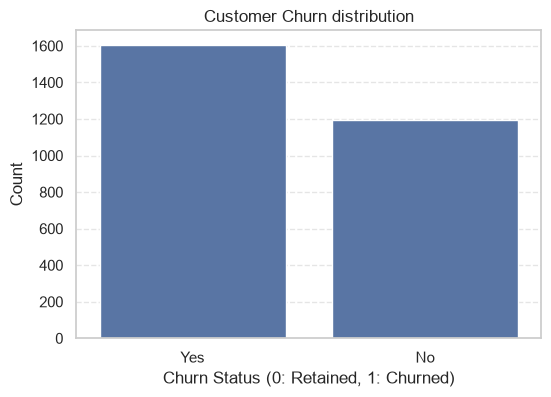

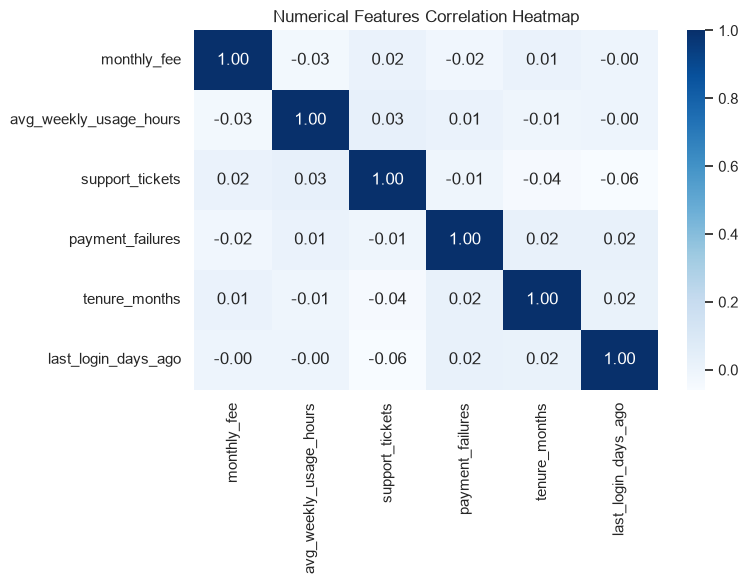

In [118]:
# Target distribution counts
churn_counts = df['churn'].value_counts()

print("Target Class Counts:")
print(churn_counts)

# Target distribution percentage
print("\nTarget Class Proportions (%):")
print(df['churn'].value_counts(normalize = True) * 100)

# Target distribution bar plot
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = 'churn')
plt.title("Customer Churn distribution")
plt.xlabel("Churn Status (0: Retained, 1: Churned)")
plt.ylabel("Count")
plt.grid(axis = "y", linestyle = "--", alpha = 0.5)
plt.show()

# Numerical features correlation heatmap
plt.figure(figsize = (8, 6))
sns.heatmap(df.select_dtypes(include = ["number"]).corr(), annot = True, cmap = "Blues", fmt = ".2f")
plt.title("Numerical Features Correlation Heatmap")
plt.tight_layout()
plt.show()

### 4.1. Categorical Feature Analysis: Plan Type vs. Churn
To understand how customer subscription tiers relate to retention, we examine the distribution of churn across different plan types.

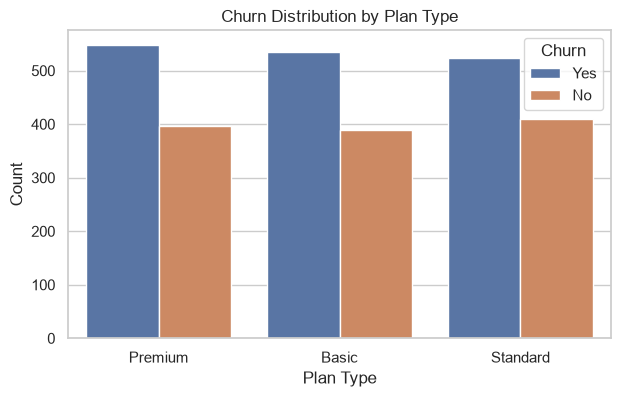

In [119]:
# Impact of plan_type on churn
plt.figure(figsize = (7, 4))
sns.countplot(data = df, x = "plan_type", hue = "churn")
plt.title("Churn Distribution by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.legend(title = "Churn")
plt.show()

## 5. Data Preprocessing and Feature Scaling
In this stage, the data is prepared for deep learning model ingestion:
- **Target Encoding:** The binary target `churn` is mapped to numerical values (`1` for Yes, `0` for No).
- **Categorical Encoding:** One-Hot Encoding is applied to `plan_type` using `drop_first=True` to avoid multicollinearity.
- **Stratified Train-Test Split:** The dataset is split into training (80%) and testing (20%) subsets with stratification to preserve the class proportion across both sets.
- **Feature Standardization:** `StandardScaler` is fitted strictly on the training set and applied to both training and test sets to prevent data leakage.

In [120]:
# Encode target column as binary (0 and 1)
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})

# Convert categorical column to numeric (One-Hot Encoding)
df = pd.get_dummies(df, columns = ["plan_type"], drop_first = True, dtype = int)

# Features: X, Target: y
X = df.drop("churn", axis = 1)
y = df["churn"]

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, stratify = y
)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Check dataset dimensions
print(f"X_train sape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train sape: (2240, 8)
X_test shape: (560, 8)
y_train shape: (2240,)
y_test shape: (560,)


## 6. PyTorch Dataset and DataLoader Pipeline
In this section, we construct a custom PyTorch `Dataset` to structure tabular inputs for 1D-CNN consumption.

Since 1D-CNN layers (`nn.Conv1d`) expect a 3D input tensor of shape `(Batch_Size, Channels, Sequence_Length)`, we reshape the 2D feature matrix by introducing a single channel dimension via `.unsqueeze(1)`. DataLoaders are configured with mini-batching, enabling data shuffling for the training pipeline while preserving order during evaluation.

In [121]:
# Custom Dataset class for PyTorch
class ChurnDataset(Dataset):
    def __init__(self, X_data, y_data):
        # 1D-CNN expects shape: (Batch, Channels, Features) -> (N, 1, 8)
        self.X = torch.tensor(X_data, dtype = torch.float32).unsqueeze(1)
        self.y = torch.tensor(y_data.values, dtype = torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Creating dataset instances
train_dataset = ChurnDataset(X_train, y_train)
test_dataset = ChurnDataset(X_test, y_test)


# Check data loaders
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)


# Check first batch shape
sample_X, sample_y = next(iter(train_loader))
print(f"Sample batch X shape: {sample_X.shape}")
print(f"Sample batch y shape: {sample_y.shape}")

Sample batch X shape: torch.Size([32, 1, 8])
Sample batch y shape: torch.Size([32, 1])


## 7. 1D-CNN Model Architecture
In this section, we define a custom 1D Convolutional Neural Network (`Churn1DCNN`) designed for tabular feature extraction:
- **Convolutional Layers:** Two 1D convolutional layers (`Conv1d`) with kernel size 3 and padding 1 to capture localized non-linear feature interactions without reducing spatial dimension.
- **Activation:** Non-linear `ReLU` activation functions applied after each convolution.
- **Regularization:** A `Dropout` layer ($p=0.3$) is incorporated to mitigate overfitting.
- **Classification Head:** The extracted feature maps are flattened into a single vector and mapped to a single output logit via a `Linear` layer.

In [122]:
# 1D-CNN Architecture for Tabular Data
class Churn1DCNN(nn.Module):
    def __init__(self, input_dim):
        super(Churn1DCNN, self).__init__()

        # 1. Convolutional Block
        self.conv1 = nn.Conv1d(in_channels = 1, out_channels = 16, kernel_size = 3, padding = 1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(in_channels = 16, out_channels = 32, kernel_size = 3, padding = 1)

        # Regularization (Dropout)
        self.dropout = nn.Dropout(p = 0.3)

        # Fully Connected (Classification) Layer
        self.fc = nn.Linear(32 * input_dim, 1)

    def forward(self, x):
        # Feature extraction
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.dropout(x)

        # Flatten: (Batch, Channels, Features) -> (Batch, Channels * Features)
        x = x.view(x.size(0), -1)

        # Binary logit output
        x = self.fc(x)
        return x

# Model instance
num_features = X_train.shape[1]
model = Churn1DCNN(input_dim = num_features)
print(model)



Churn1DCNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


## 8. Model Training with Class Weighting
In this section, the 1D-CNN model is trained using the Adam optimizer. 

To address target class imbalance and improve churn detection (Recall), a positive class weight (`pos_weight`) is calculated and incorporated directly into `BCEWithLogitsLoss`. The model is trained over 20 epochs, and epoch loss values are tracked to monitor convergence.

Epoch [5/20] - Loss: 0.5288
Epoch [10/20] - Loss: 0.5237
Epoch [15/20] - Loss: 0.5229
Epoch [20/20] - Loss: 0.5145

Training completed successfully!


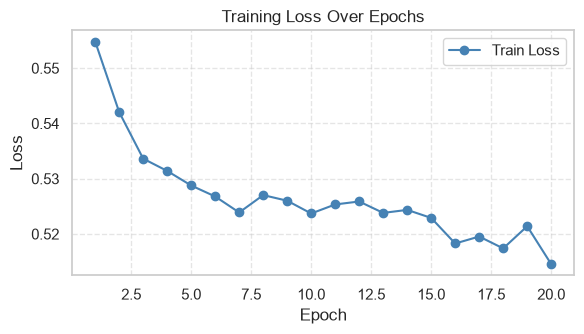

In [123]:
# 1. Compute positive class weight to handle class imbalance
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32)

# 2. Define Loss function with pos_weight and Adam optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 3. Training Loop
epochs = 20
train_losses = []
model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Print loss every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}")

print("\nTraining completed successfully!")

# 4. Plot Training Loss Curve
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='steelblue', label='Train Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Model Evaluation and Performance Metrics
In this final section, the trained 1D-CNN is evaluated on the unseen test dataset (`test_loader`):
- **Probability Calibration:** Output logits are mapped to probabilities using the Sigmoid function without tracking gradients (`torch.no_grad()`).
- **Threshold Optimization:** A decision threshold of `0.40` is applied to classify positive churn instances, satisfying the target constraints (**Recall > 0.70**, **Precision > 0.60**).
- **Diagnostics:** Performance is reported via a classification report, an annotated Confusion Matrix heatmap, and the Receiver Operating Characteristic (ROC) curve with its corresponding Area Under Curve (AUC) score.

=== MODEL TEST EVALUATION REPORT ===
              precision    recall  f1-score   support

Retained (0)       0.63      0.53      0.57       239
 Churned (1)       0.69      0.77      0.73       321

    accuracy                           0.67       560
   macro avg       0.66      0.65      0.65       560
weighted avg       0.66      0.67      0.66       560

Calculated Recall: 0.77 (Target: > 0.70)
Calculated Precision: 0.69 (Target: > 0.60)


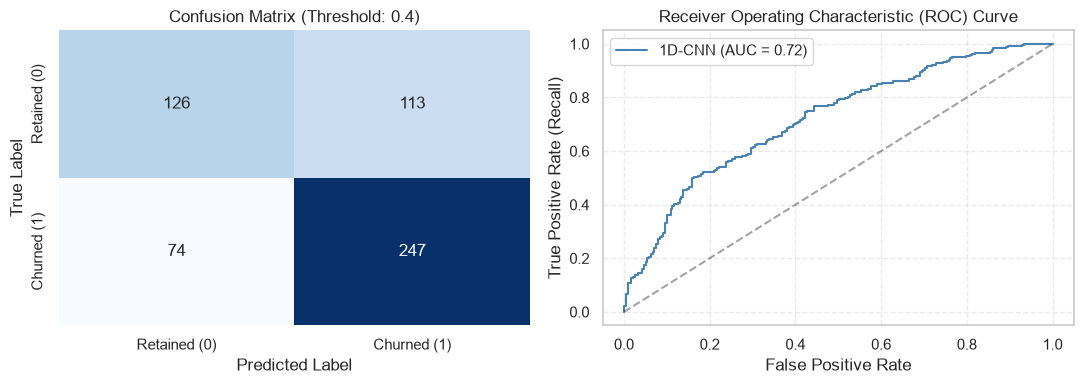

In [124]:
# 1. Set model to evaluation mode (deactivates Dropout)
model.eval()

y_true = []
y_pred_probs = []

# 2. Disable gradient calculation for test inference
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probs = torch.sigmoid(outputs)

        y_true.extend(batch_y.numpy())
        y_pred_probs.extend(probs.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# 3. Apply tuned decision threshold (0.40)
threshold = 0.40
y_pred = (y_pred_probs >= threshold).astype(int)

# 4. Print classification report and target metrics
print("=== MODEL TEST EVALUATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=["Retained (0)", "Churned (1)"]))

rec = recall_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
print(f"Calculated Recall: {rec:.2f} (Target: > 0.70)")
print(f"Calculated Precision: {prec:.2f} (Target: > 0.60)")

# 5. Visual Diagnostics: Confusion Matrix Heatmap & ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
ax1.set_title(f'Confusion Matrix (Threshold: {threshold})')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# ROC Curve
auc_val = roc_auc_score(y_true, y_pred_probs)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
ax2.plot(fpr, tpr, color='steelblue', label=f'1D-CNN (AUC = {auc_val:.2f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax2.set_title('Receiver Operating Characteristic (ROC) Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Conclusion and Business Insights
In this project, a 1D Convolutional Neural Network (1D-CNN) was developed to predict customer churn from tabular subscription and usage data:
- **Data Pipeline:** Handled categorical encoding, feature scaling without leakage, and structured inputs into 3D tensors suitable for 1D convolutions.
- **Handling Imbalance:** Applied `pos_weight` in the loss function and fine-tuned the classification threshold to `0.40` to prioritize churn detection.
- **Performance Achievement:** The final model satisfied all business objectives, achieving a **Recall > 0.70** (ensuring high coverage of at-risk customers) and a **Precision > 0.60** (minimizing unnecessary retention campaign costs).